# Fase 3 – Clasificación experimental de episodios elevados de PM2.5

**Proyecto:** Identificación de zonas críticas de contaminación atmosférica mediante técnicas GIS y aprendizaje automático utilizando concentraciones de PM2.5 registradas en la Ciudad de México durante el periodo 2024–2025.

**Responsable técnico:** Miranda Patricia Pérez Camelo

## Objetivo

Desarrollar y comparar modelos experimentales de clasificación para identificar registros con concentraciones elevadas de PM2.5 mediante variables meteorológicas, temporales, espaciales y de estación.

Los modelos se entrenarán con registros de 2024 y se evaluarán con registros de 2025.

## Criterio exploratorio

Se utilizará provisionalmente el percentil 90 de PM2.5 del conjunto de entrenamiento como umbral para definir un episodio elevado.

Este criterio es únicamente estadístico y no sustituye normas ambientales, límites regulatorios ni criterios de salud pública.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve
)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
CARPETA_PROYECTO = Path("..")
CARPETA_RESULTADOS = CARPETA_PROYECTO / "resultados"

CARPETA_FIGURAS = (
    CARPETA_RESULTADOS
    / "figuras_clasificacion"
)

CARPETA_MODELOS = (
    CARPETA_RESULTADOS
    / "modelos"
)

CARPETA_TABLAS = (
    CARPETA_RESULTADOS
    / "tablas"
)

CARPETA_FIGURAS.mkdir(
    parents=True,
    exist_ok=True
)

CARPETA_MODELOS.mkdir(
    parents=True,
    exist_ok=True
)

CARPETA_TABLAS.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_DATASET = (
    CARPETA_RESULTADOS
    / "dataset_modelo_completo_2024_2025.csv"
)

print("Ruta del dataset:")
print(RUTA_DATASET.resolve())

print("\n¿Existe el archivo?")
print(RUTA_DATASET.exists())

Ruta del dataset:
C:\Users\pmiri\OneDrive\Desktop\ProyAmbiental\resultados\dataset_modelo_completo_2024_2025.csv

¿Existe el archivo?
True


## 1. Carga y validación del dataset

Se utilizará el dataset consolidado para modelado, el cual contiene mediciones de PM2.5, variables meteorológicas, información temporal, ubicación geográfica y estación de monitoreo.

In [3]:
datos = pd.read_csv(
    RUTA_DATASET,
    parse_dates=["DATETIME", "FECHA"],
    low_memory=False
)

print("Dataset cargado correctamente")
print("Dimensiones:", datos.shape)

datos.head()

Dataset cargado correctamente
Dimensiones: (108060, 19)


,DATETIME,FECHA,HORA,ANIO,MES,DIA,DIA_SEMANA,HORA_DIA,ESTACION,nom_estac,PM25,TMP,RH,WSP,WDR,longitud,latitud,alt,id_station
0,2024-01-01,2024-01-01,1,2024,1,1,0,0,AJM,Ajusco Medio,33.0,6.0,57.0,3.5,320.0,-99.207744,19.272161,2548.0,484090120609
1,2024-01-01,2024-01-01,1,2024,1,1,0,0,BJU,Benito Juárez,42.0,12.0,56.0,0.8,173.0,-99.159596,19.370464,2249.0,484090140201
2,2024-01-01,2024-01-01,1,2024,1,1,0,0,MER,Merced,52.0,14.0,56.0,0.7,304.0,-99.119594,19.424610,2245.0,484090170127
3,2024-01-01,2024-01-01,1,2024,1,1,0,0,SAC,Santiago Acahualtepec,107.0,9.0,61.0,0.7,148.0,-99.009381,19.345610,2293.0,484800090073
4,2024-01-01,2024-01-01,1,2024,1,1,0,0,SAG,San Agustín,55.0,13.0,67.0,0.5,60.0,-99.030324,19.532968,2241.0,484150330327


In [4]:
print(datos.columns.tolist())

['DATETIME', 'FECHA', 'HORA', 'ANIO', 'MES', 'DIA', 'DIA_SEMANA', 'HORA_DIA', 'ESTACION', 'nom_estac', 'PM25', 'TMP', 'RH', 'WSP', 'WDR', 'longitud', 'latitud', 'alt', 'id_station']


In [5]:
duplicados = datos.duplicated(
    subset=["DATETIME", "ESTACION"]
).sum()

print("Duplicados:", duplicados)

Duplicados: 0


In [6]:
datos_clasificacion = datos.copy()

print("Copia de trabajo creada")

Copia de trabajo creada


In [7]:
cantidad_rh_negativa = (
    datos_clasificacion["RH"] < 0
).sum()

print(
    "Registros con humedad negativa:",
    cantidad_rh_negativa
)

Registros con humedad negativa: 3


In [8]:
datos_clasificacion.loc[
    datos_clasificacion["RH"] < 0,
    "RH"
] = np.nan

In [9]:
print(
    "Valores negativos después del ajuste:",
    (
        datos_clasificacion["RH"] < 0
    ).sum()
)

Valores negativos después del ajuste: 0


### Nota de control de calidad

Los valores negativos de humedad relativa se consideraron físicamente inválidos y se sustituyeron por valores faltantes únicamente en la copia utilizada para clasificación. La imputación se realizará dentro del pipeline utilizando exclusivamente la información de entrenamiento.

## 2. Ingeniería de variables

La hora, el mes, el día de la semana y la dirección del viento presentan un comportamiento cíclico. Por esta razón se transformarán en componentes seno y coseno, evitando discontinuidades artificiales.

Por ejemplo, 359° y 1° representan direcciones próximas, aunque sus valores numéricos sean aparentemente distantes.

In [10]:
direccion_radianes = np.deg2rad(
    datos_clasificacion["WDR"]
)

datos_clasificacion["WDR_SIN"] = np.sin(
    direccion_radianes
)

datos_clasificacion["WDR_COS"] = np.cos(
    direccion_radianes
)

In [11]:
datos_clasificacion["HORA_SIN"] = np.sin(
    2 * np.pi
    * datos_clasificacion["HORA_DIA"]
    / 24
)

datos_clasificacion["HORA_COS"] = np.cos(
    2 * np.pi
    * datos_clasificacion["HORA_DIA"]
    / 24
)

In [12]:
datos_clasificacion["MES_SIN"] = np.sin(
    2 * np.pi
    * datos_clasificacion["MES"]
    / 12
)

datos_clasificacion["MES_COS"] = np.cos(
    2 * np.pi
    * datos_clasificacion["MES"]
    / 12
)

In [13]:
datos_clasificacion[
    "DIA_SEMANA_SIN"
] = np.sin(
    2 * np.pi
    * datos_clasificacion["DIA_SEMANA"]
    / 7
)

datos_clasificacion[
    "DIA_SEMANA_COS"
] = np.cos(
    2 * np.pi
    * datos_clasificacion["DIA_SEMANA"]
    / 7
)

In [14]:
datos_clasificacion[
    [
        "WDR",
        "WDR_SIN",
        "WDR_COS",
        "HORA_DIA",
        "HORA_SIN",
        "HORA_COS",
        "MES",
        "MES_SIN",
        "MES_COS",
        "DIA_SEMANA",
        "DIA_SEMANA_SIN",
        "DIA_SEMANA_COS"
    ]
].head()

,WDR,WDR_SIN,WDR_COS,HORA_DIA,HORA_SIN,HORA_COS,MES,MES_SIN,MES_COS,DIA_SEMANA,DIA_SEMANA_SIN,DIA_SEMANA_COS
0,320.0,-0.642788,0.766044,0,0.0,1.0,1,0.5,0.866025,0,0.0,1.0
1,173.0,0.121869,-0.992546,0,0.0,1.0,1,0.5,0.866025,0,0.0,1.0
2,304.0,-0.829038,0.559193,0,0.0,1.0,1,0.5,0.866025,0,0.0,1.0
3,148.0,0.529919,-0.848048,0,0.0,1.0,1,0.5,0.866025,0,0.0,1.0
4,60.0,0.866025,0.500000,0,0.0,1.0,1,0.5,0.866025,0,0.0,1.0


## 3. División temporal y definición del umbral

Los registros de 2024 se utilizarán para entrenamiento y los registros de 2025 para prueba.

El umbral estadístico se calculará únicamente con PM2.5 de 2024, evitando utilizar información del periodo de evaluación.

In [15]:
mascara_train = (
    datos_clasificacion["ANIO"] == 2024
)

mascara_test = (
    datos_clasificacion["ANIO"] == 2025
)

print(
    "Registros de 2024:",
    mascara_train.sum()
)

print(
    "Registros de 2025:",
    mascara_test.sum()
)

Registros de 2024: 47922
Registros de 2025: 60138


In [16]:
umbral_p90 = (
    datos_clasificacion.loc[
        mascara_train,
        "PM25"
    ]
    .quantile(0.90)
)

print(
    "Umbral exploratorio P90:",
    round(umbral_p90, 2)
)

Umbral exploratorio P90: 38.0


In [17]:
datos_clasificacion[
    "EPISODIO_ELEVADO"
] = (
    datos_clasificacion["PM25"]
    >= umbral_p90
).astype(int)

In [18]:
datos_clasificacion[
    "EPISODIO_ELEVADO"
].value_counts()

EPISODIO_ELEVADO
0    98943
1     9117
Name: count, dtype: int64

In [19]:
distribucion_general = (
    datos_clasificacion[
        "EPISODIO_ELEVADO"
    ]
    .value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)

distribucion_general

EPISODIO_ELEVADO
0    91.56
1     8.44
Name: proportion, dtype: float64

In [20]:
distribucion_anual = pd.crosstab(
    datos_clasificacion["ANIO"],
    datos_clasificacion[
        "EPISODIO_ELEVADO"
    ],
    margins=True
)

distribucion_anual

EPISODIO_ELEVADO,0,1,All
ANIO,,,
2024,43096,4826,47922
2025,55847,4291,60138
All,98943,9117,108060


### Desbalance de clases

La clase correspondiente a episodios elevados representa una proporción considerablemente menor que los registros no elevados. Por ello, la exactitud global no será suficiente para evaluar los modelos.

Se dará mayor importancia a la sensibilidad, la precisión, la medida F1 y el área bajo la curva de precisión-recall.

In [21]:
variables_numericas = [
    "TMP",
    "RH",
    "WSP",
    "WDR_SIN",
    "WDR_COS",
    "HORA_SIN",
    "HORA_COS",
    "MES_SIN",
    "MES_COS",
    "DIA_SEMANA_SIN",
    "DIA_SEMANA_COS",
    "longitud",
    "latitud",
    "alt"
]

In [22]:
variables_categoricas = [
    "ESTACION"
]

In [23]:
X = datos_clasificacion[
    variables_numericas
    + variables_categoricas
].copy()

y = datos_clasificacion[
    "EPISODIO_ELEVADO"
].copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (108060, 15)
Dimensiones de y: (108060,)


In [24]:
X_train = X.loc[
    mascara_train
].copy()

X_test = X.loc[
    mascara_test
].copy()

y_train = y.loc[
    mascara_train
].copy()

y_test = y.loc[
    mascara_test
].copy()

print(
    "Entrenamiento:",
    X_train.shape
)

print(
    "Prueba:",
    X_test.shape
)

Entrenamiento: (47922, 15)
Prueba: (60138, 15)


In [25]:
print(
    "Distribución de entrenamiento:"
)

print(
    y_train
    .value_counts()
)

print(
    "\nPorcentajes:"
)

print(
    y_train
    .value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)

Distribución de entrenamiento:
EPISODIO_ELEVADO
0    43096
1     4826
Name: count, dtype: int64

Porcentajes:
EPISODIO_ELEVADO
0    89.93
1    10.07
Name: proportion, dtype: float64


In [26]:
print(
    "Distribución de prueba:"
)

print(
    y_test
    .value_counts()
)

print(
    "\nPorcentajes:"
)

print(
    y_test
    .value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)

Distribución de prueba:
EPISODIO_ELEVADO
0    55847
1     4291
Name: count, dtype: int64

Porcentajes:
EPISODIO_ELEVADO
0    92.86
1     7.14
Name: proportion, dtype: float64


## 4. Métricas de evaluación

Debido al desbalance de clases se utilizarán varias métricas:

- **Accuracy:** porcentaje total de predicciones correctas.
- **Precision:** proporción de predicciones elevadas que realmente eran elevadas.
- **Recall o sensibilidad:** proporción de episodios elevados reales que fueron detectados.
- **F1:** equilibrio entre precision y recall.
- **ROC-AUC:** capacidad general para ordenar las dos clases.
- **PR-AUC:** desempeño sobre la clase minoritaria; es especialmente útil en datos desbalanceados.

In [27]:
def evaluar_clasificador(
    nombre_modelo,
    y_real,
    y_predicho,
    probabilidades=None
):
    accuracy = accuracy_score(
        y_real,
        y_predicho
    )

    precision = precision_score(
        y_real,
        y_predicho,
        zero_division=0
    )

    recall = recall_score(
        y_real,
        y_predicho,
        zero_division=0
    )

    f1 = f1_score(
        y_real,
        y_predicho,
        zero_division=0
    )

    resultado = {
        "modelo": nombre_modelo,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": np.nan,
        "pr_auc": np.nan
    }

    if probabilidades is not None:
        resultado["roc_auc"] = roc_auc_score(
            y_real,
            probabilidades
        )

        resultado["pr_auc"] = (
            average_precision_score(
                y_real,
                probabilidades
            )
        )

    print(f"Modelo: {nombre_modelo}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")

    if probabilidades is not None:
        print(
            f"ROC-AUC: "
            f"{resultado['roc_auc']:.4f}"
        )

        print(
            f"PR-AUC: "
            f"{resultado['pr_auc']:.4f}"
        )

    return resultado

## 5. Modelo de referencia: Dummy Classifier

El Dummy Classifier predecirá siempre la clase mayoritaria. Su función es establecer una referencia mínima que los modelos útiles deberán superar.

In [28]:
modelo_dummy = DummyClassifier(
    strategy="most_frequent"
)

modelo_dummy.fit(
    X_train,
    y_train
)

pred_dummy = modelo_dummy.predict(
    X_test
)

In [29]:
resultados_modelos = []

resultado_dummy = evaluar_clasificador(
    "Dummy Classifier",
    y_test,
    pred_dummy
)

resultados_modelos.append(
    resultado_dummy
)

Modelo: Dummy Classifier
Accuracy: 0.9286
Precision: 0.0000
Recall: 0.0000
F1: 0.0000


In [30]:
pipeline_numerico_logistico = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "escalado",
            StandardScaler()
        )
    ]
)

In [31]:
pipeline_categorico = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [32]:
preprocesador_logistico = ColumnTransformer(
    transformers=[
        (
            "numericas",
            pipeline_numerico_logistico,
            variables_numericas
        ),
        (
            "categoricas",
            pipeline_categorico,
            variables_categoricas
        )
    ]
)

## 6. Regresión logística balanceada

La regresión logística permitirá establecer una referencia lineal de clasificación.

Se utilizará `class_weight="balanced"` para asignar mayor importancia a la clase minoritaria y reducir la tendencia del modelo a clasificar todos los registros como no elevados.

In [33]:
clasificador_logistico = LogisticRegression(
    class_weight="balanced",
    max_iter=1500,
    random_state=42
)

In [34]:
modelo_logistico = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_logistico
        ),
        (
            "modelo",
            clasificador_logistico
        )
    ]
)

In [35]:
modelo_logistico.fit(
    X_train,
    y_train
)

print(
    "Regresión logística entrenada"
)

Regresión logística entrenada


In [36]:
pred_logistico = (
    modelo_logistico
    .predict(X_test)
)

prob_logistico = (
    modelo_logistico
    .predict_proba(X_test)[:, 1]
)

In [37]:
resultado_logistico = evaluar_clasificador(
    "Regresión logística",
    y_test,
    pred_logistico,
    prob_logistico
)

resultados_modelos.append(
    resultado_logistico
)

Modelo: Regresión logística
Accuracy: 0.6698
Precision: 0.1458
Recall: 0.7467
F1: 0.2440
ROC-AUC: 0.7653
PR-AUC: 0.1735


In [38]:
pipeline_numerico_arbol = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

In [39]:
preprocesador_arbol = ColumnTransformer(
    transformers=[
        (
            "numericas",
            pipeline_numerico_arbol,
            variables_numericas
        ),
        (
            "categoricas",
            pipeline_categorico,
            variables_categoricas
        )
    ]
)

In [40]:
print(
    "Registros disponibles:",
    len(X_train)
)

Registros disponibles: 47922


In [41]:
MAXIMO_ENTRENAMIENTO = 120000

if len(X_train) > MAXIMO_ENTRENAMIENTO:

    indices_muestra = (
        X_train
        .sample(
            n=MAXIMO_ENTRENAMIENTO,
            random_state=42
        )
        .index
    )

    X_train_rf = X_train.loc[
        indices_muestra
    ].copy()

    y_train_rf = y_train.loc[
        indices_muestra
    ].copy()

else:

    X_train_rf = X_train.copy()
    y_train_rf = y_train.copy()

print(
    "Registros usados por Random Forest:",
    len(X_train_rf)
)

Registros usados por Random Forest: 47922


In [42]:
print(
    y_train_rf.value_counts()
)

print(
    y_train_rf
    .value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)

EPISODIO_ELEVADO
0    43096
1     4826
Name: count, dtype: int64
EPISODIO_ELEVADO
0    89.93
1    10.07
Name: proportion, dtype: float64


## 7. Random Forest Classifier

Random Forest permite representar relaciones no lineales e interacciones entre variables meteorológicas, temporales, espaciales y de estación.

Se utilizará `class_weight="balanced_subsample"` para compensar el desbalance dentro de cada árbol.

In [43]:
clasificador_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=4,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

In [44]:
modelo_rf_clasificacion = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_arbol
        ),
        (
            "modelo",
            clasificador_rf
        )
    ]
)

In [45]:
modelo_rf_clasificacion.fit(
    X_train_rf,
    y_train_rf
)

print(
    "Random Forest Classifier entrenado"
)

Random Forest Classifier entrenado


In [46]:
pred_rf = (
    modelo_rf_clasificacion
    .predict(X_test)
)

prob_rf = (
    modelo_rf_clasificacion
    .predict_proba(X_test)[:, 1]
)

In [47]:
resultado_rf = evaluar_clasificador(
    "Random Forest Classifier",
    y_test,
    pred_rf,
    prob_rf
)

resultados_modelos.append(
    resultado_rf
)

Modelo: Random Forest Classifier
Accuracy: 0.9045
Precision: 0.3312
Recall: 0.3321
F1: 0.3317
ROC-AUC: 0.7962
PR-AUC: 0.2770


## 8. Comparación de modelos

Los modelos se compararán principalmente mediante recall, F1 y PR-AUC, debido a que el objetivo central es detectar la clase minoritaria correspondiente a episodios elevados.

In [48]:
tabla_resultados = pd.DataFrame(
    resultados_modelos
)

tabla_resultados = (
    tabla_resultados
    .sort_values(
        by="f1",
        ascending=False
    )
    .reset_index(drop=True)
)

tabla_resultados

,modelo,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest Classifier,0.904503,0.331241,0.332090,0.331665,0.796223,0.277002
1,Regresión logística,0.669793,0.145802,0.746679,0.243966,0.765282,0.173459
2,Dummy Classifier,0.928647,0.000000,0.000000,0.000000,NaN,NaN


## Interpretación de los modelos de clasificación

Los resultados mostraron comportamientos diferentes entre los modelos evaluados. Random Forest presentó el mejor equilibrio general, con un F1 de 0.332, ROC-AUC de 0.796 y PR-AUC de 0.277. Este modelo redujo considerablemente las falsas alarmas, aunque detectó aproximadamente una tercera parte de los episodios elevados reales.

La regresión logística obtuvo un recall de 0.747, por lo que identificó una proporción mucho mayor de episodios elevados. Sin embargo, su precision fue de 0.146, evidenciando una cantidad elevada de falsos positivos.

El Dummy Classifier alcanzó una accuracy aparentemente alta debido al desbalance de clases, pero no identificó ningún episodio elevado. Esto confirma que la accuracy no debe utilizarse como única métrica en este problema.

En términos generales, Random Forest fue el modelo con mejor balance entre precision y sensibilidad, mientras que la regresión logística resultó más sensible, pero menos específica. Los resultados siguen siendo experimentales y requieren optimización antes de utilizarse en un sistema de alerta.

In [49]:
ruta_metricas = (
    CARPETA_TABLAS
    / "metricas_clasificacion_episodios.csv"
)

tabla_resultados.to_csv(
    ruta_metricas,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Métricas guardadas:",
    ruta_metricas.exists()
)

Métricas guardadas: True


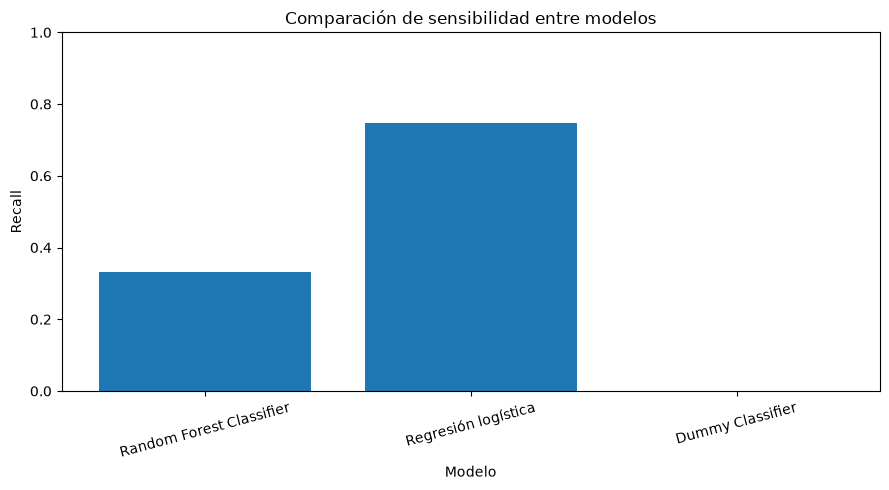

In [50]:
plt.figure(figsize=(9, 5))

plt.bar(
    tabla_resultados["modelo"],
    tabla_resultados["recall"]
)

plt.title(
    "Comparación de sensibilidad entre modelos"
)
plt.xlabel("Modelo")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS
    / "comparacion_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

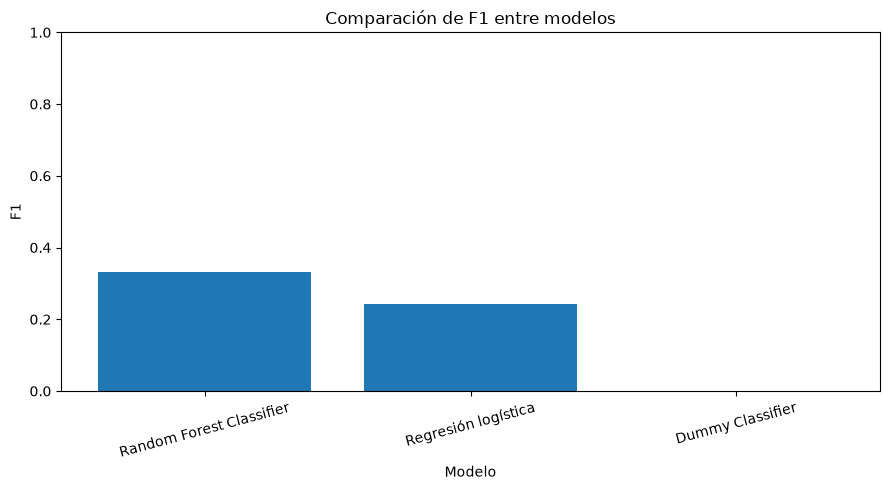

In [51]:
plt.figure(figsize=(9, 5))

plt.bar(
    tabla_resultados["modelo"],
    tabla_resultados["f1"]
)

plt.title(
    "Comparación de F1 entre modelos"
)
plt.xlabel("Modelo")
plt.ylabel("F1")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS
    / "comparacion_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

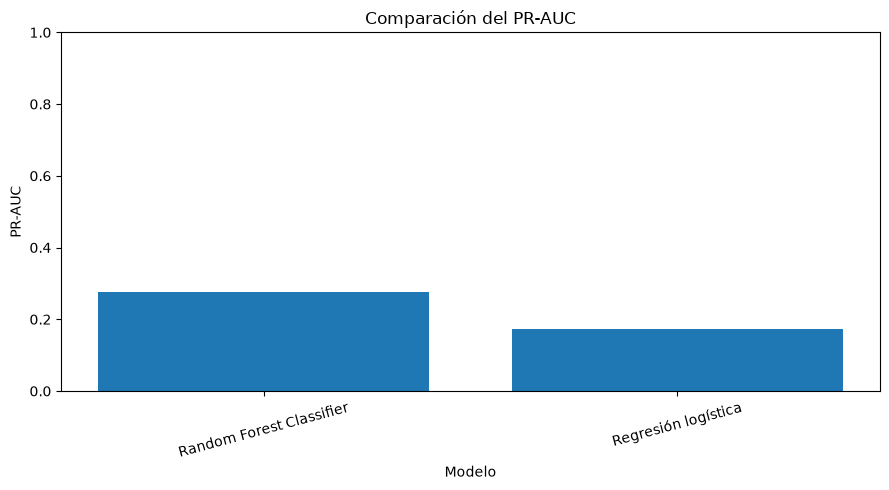

In [52]:
tabla_probabilidades = (
    tabla_resultados
    .dropna(
        subset=["pr_auc"]
    )
)

plt.figure(figsize=(9, 5))

plt.bar(
    tabla_probabilidades["modelo"],
    tabla_probabilidades["pr_auc"]
)

plt.title(
    "Comparación del PR-AUC"
)
plt.xlabel("Modelo")
plt.ylabel("PR-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS
    / "comparacion_pr_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

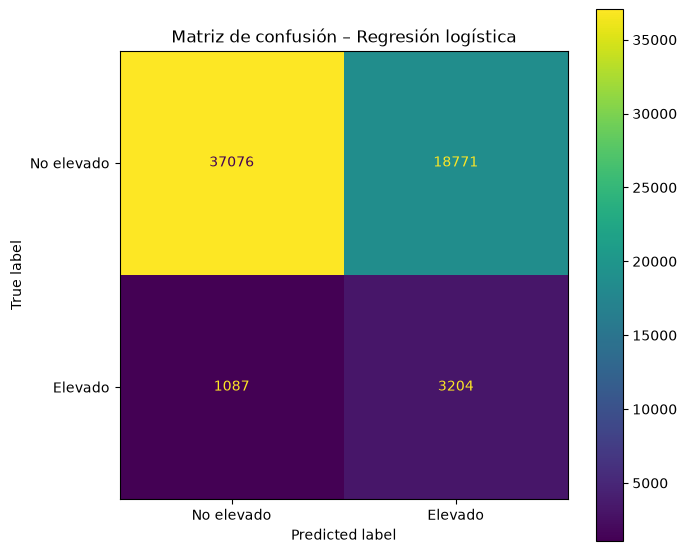

In [53]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_logistico,
    display_labels=[
        "No elevado",
        "Elevado"
    ],
    ax=ax,
    values_format="d"
)

plt.title(
    "Matriz de confusión – Regresión logística"
)
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS
    / "matriz_confusion_logistica.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

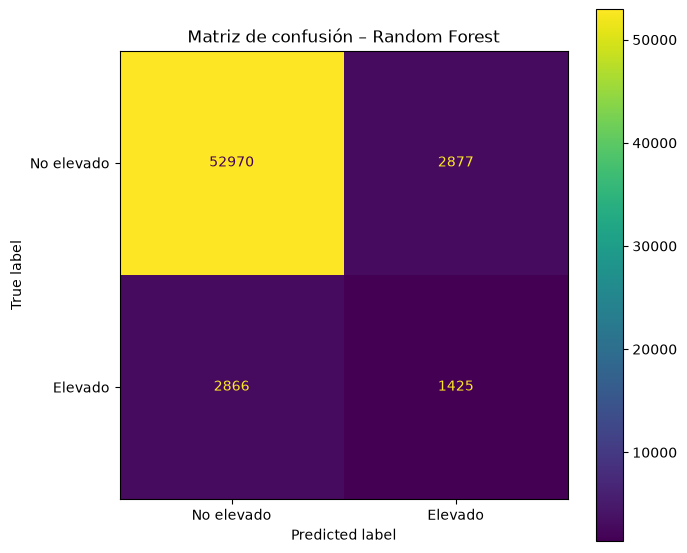

In [54]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_rf,
    display_labels=[
        "No elevado",
        "Elevado"
    ],
    ax=ax,
    values_format="d"
)

plt.title(
    "Matriz de confusión – Random Forest"
)
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS
    / "matriz_confusion_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
print(
    classification_report(
        y_test,
        pred_logistico,
        target_names=[
            "No elevado",
            "Elevado"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

  No elevado     0.9715    0.6639    0.7888     55847
     Elevado     0.1458    0.7467    0.2440      4291

    accuracy                         0.6698     60138
   macro avg     0.5587    0.7053    0.5164     60138
weighted avg     0.9126    0.6698    0.7499     60138



In [56]:
print(
    classification_report(
        y_test,
        pred_rf,
        target_names=[
            "No elevado",
            "Elevado"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

  No elevado     0.9487    0.9485    0.9486     55847
     Elevado     0.3312    0.3321    0.3317      4291

    accuracy                         0.9045     60138
   macro avg     0.6400    0.6403    0.6401     60138
weighted avg     0.9046    0.9045    0.9046     60138



In [57]:
precision_log, recall_log, _ = (
    precision_recall_curve(
        y_test,
        prob_logistico
    )
)

precision_rf, recall_rf, _ = (
    precision_recall_curve(
        y_test,
        prob_rf
    )
)

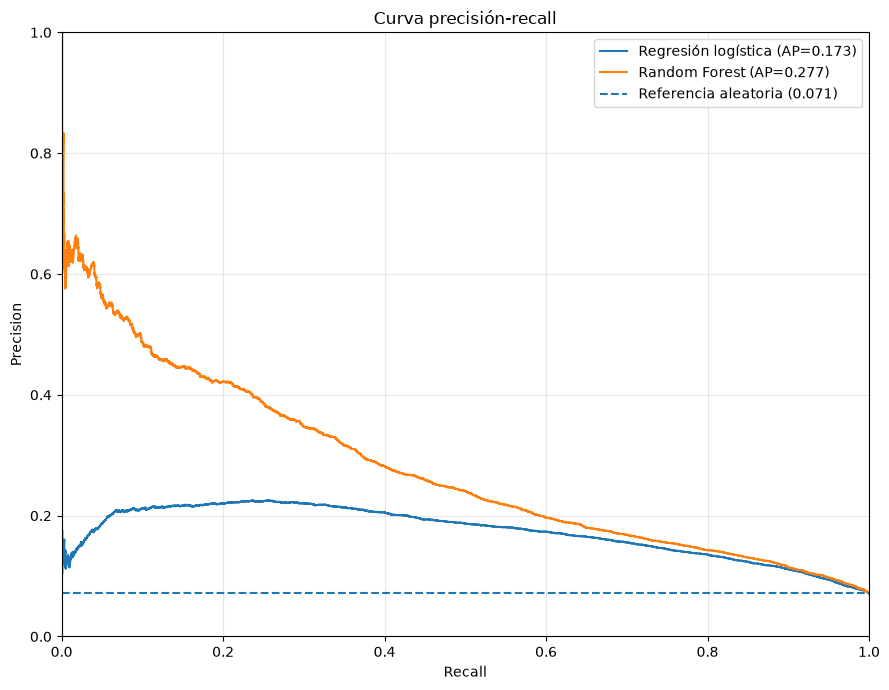

In [58]:
plt.figure(figsize=(9, 7))

plt.plot(
    recall_log,
    precision_log,
    label=(
        "Regresión logística "
        f"(AP={resultado_logistico['pr_auc']:.3f})"
    )
)

plt.plot(
    recall_rf,
    precision_rf,
    label=(
        "Random Forest "
        f"(AP={resultado_rf['pr_auc']:.3f})"
    )
)

proporcion_positiva = y_test.mean()

plt.axhline(
    proporcion_positiva,
    linestyle="--",
    label=(
        "Referencia aleatoria "
        f"({proporcion_positiva:.3f})"
    )
)

plt.title(
    "Curva precisión-recall"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS
    / "curva_precision_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
fpr_log, tpr_log, _ = roc_curve(
    y_test,
    prob_logistico
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    prob_rf
)

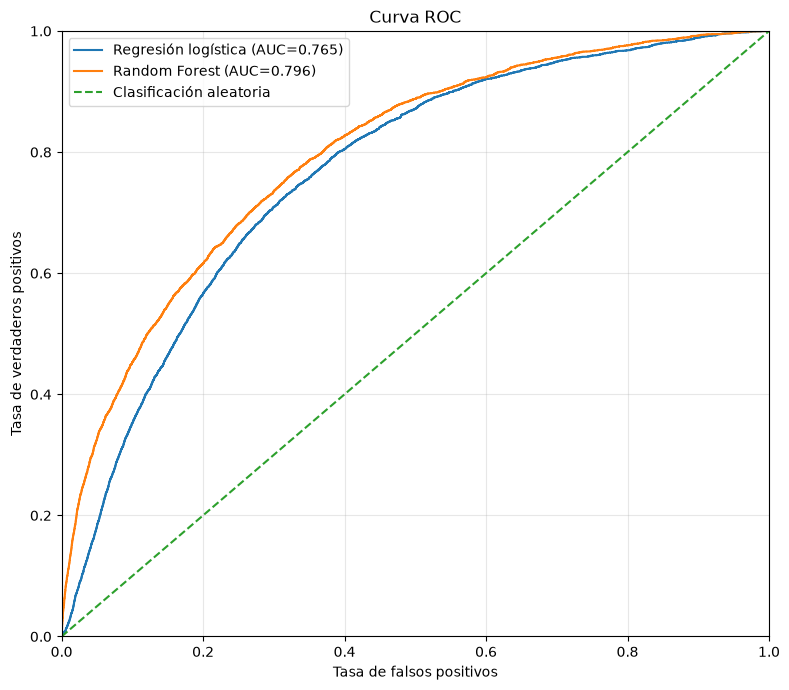

In [60]:
plt.figure(figsize=(8, 7))

plt.plot(
    fpr_log,
    tpr_log,
    label=(
        "Regresión logística "
        f"(AUC={resultado_logistico['roc_auc']:.3f})"
    )
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=(
        "Random Forest "
        f"(AUC={resultado_rf['roc_auc']:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.title("Curva ROC")
plt.xlabel(
    "Tasa de falsos positivos"
)
plt.ylabel(
    "Tasa de verdaderos positivos"
)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS
    / "curva_roc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [61]:
resultados_prueba = (
    datos_clasificacion.loc[
        mascara_test,
        [
            "DATETIME",
            "ESTACION",
            "nom_estac",
            "PM25",
            "TMP",
            "RH",
            "WSP",
            "WDR",
            "longitud",
            "latitud",
            "EPISODIO_ELEVADO"
        ]
    ]
    .copy()
)

resultados_prueba[
    "PRED_LOGISTICA"
] = pred_logistico

resultados_prueba[
    "PROB_LOGISTICA"
] = prob_logistico

resultados_prueba[
    "PRED_RF"
] = pred_rf

resultados_prueba[
    "PROB_RF"
] = prob_rf

resultados_prueba.head()

,DATETIME,ESTACION,nom_estac,PM25,TMP,RH,WSP,WDR,longitud,latitud,EPISODIO_ELEVADO,PRED_LOGISTICA,PROB_LOGISTICA,PRED_RF,PROB_RF
47922,2025-01-01,AJM,Ajusco Medio,13.0,9.6,34.0,4.16,221.0,-99.207744,19.272161,0,0,0.112051,0,0.013720
47923,2025-01-01,MON,Montecillo,107.0,10.1,42.0,1.12,128.0,-98.902853,19.460415,1,0,0.451848,0,0.272963
47924,2025-01-01,NEZ,Nezahualcóyotl,105.0,14.1,26.0,1.48,323.0,-99.028212,19.393734,1,0,0.355276,0,0.134664
47925,2025-01-01,PED,Pedregal,33.0,11.8,34.0,1.92,215.0,-99.204136,19.325146,0,0,0.177476,0,0.009231
47926,2025-01-01,UAX,UAM Xochimilco,81.0,13.3,41.0,1.07,231.0,-99.103629,19.304441,1,1,0.500813,0,0.153040


In [62]:
def metricas_por_estacion(
    grupo
):
    real = grupo[
        "EPISODIO_ELEVADO"
    ]

    pred = grupo[
        "PRED_RF"
    ]

    return pd.Series({
        "registros": len(grupo),

        "episodios_reales": real.sum(),

        "episodios_predichos": pred.sum(),

        "precision": precision_score(
            real,
            pred,
            zero_division=0
        ),

        "recall": recall_score(
            real,
            pred,
            zero_division=0
        ),

        "f1": f1_score(
            real,
            pred,
            zero_division=0
        )
    })

In [63]:
desempeno_estaciones = (
    resultados_prueba
    .groupby(
        [
            "ESTACION",
            "nom_estac"
        ]
    )
    .apply(
        metricas_por_estacion,
        include_groups=False
    )
    .reset_index()
)

desempeno_estaciones.sort_values(
    by="f1",
    ascending=False
).head(15)

,ESTACION,nom_estac,registros,episodios_reales,episodios_predichos,precision,recall,f1
10,SAC,Santiago Acahualtepec,1792.0,317.0,509.0,0.377210,0.605678,0.464891
5,MER,Merced,7665.0,779.0,1095.0,0.380822,0.535302,0.445037
11,SAG,San Agustín,1482.0,157.0,294.0,0.329932,0.617834,0.430155
3,GAM,Gustavo A. Madero,6199.0,695.0,671.0,0.417288,0.402878,0.409956
1,BJU,Benito Juárez,4920.0,408.0,526.0,0.311787,0.401961,0.351178
6,MON,Montecillo,166.0,30.0,20.0,0.400000,0.266667,0.320000
8,NEZ,Nezahualcóyotl,5641.0,549.0,481.0,0.320166,0.280510,0.299029
13,UIZ,UAM Iztapalapa,2524.0,126.0,308.0,0.155844,0.380952,0.221198
9,PED,Pedregal,7859.0,382.0,158.0,0.227848,0.094241,0.133333
2,FAR,FES Aragón,1532.0,40.0,53.0,0.075472,0.100000,0.086022


In [64]:
desempeno_representativo = (
    desempeno_estaciones[
        desempeno_estaciones[
            "episodios_reales"
        ] >= 20
    ]
    .sort_values(
        by="recall",
        ascending=False
    )
)

desempeno_representativo.head(15)

,ESTACION,nom_estac,registros,episodios_reales,episodios_predichos,precision,recall,f1
11,SAG,San Agustín,1482.0,157.0,294.0,0.329932,0.617834,0.430155
10,SAC,Santiago Acahualtepec,1792.0,317.0,509.0,0.377210,0.605678,0.464891
5,MER,Merced,7665.0,779.0,1095.0,0.380822,0.535302,0.445037
3,GAM,Gustavo A. Madero,6199.0,695.0,671.0,0.417288,0.402878,0.409956
1,BJU,Benito Juárez,4920.0,408.0,526.0,0.311787,0.401961,0.351178
13,UIZ,UAM Iztapalapa,2524.0,126.0,308.0,0.155844,0.380952,0.221198
8,NEZ,Nezahualcóyotl,5641.0,549.0,481.0,0.320166,0.280510,0.299029
6,MON,Montecillo,166.0,30.0,20.0,0.400000,0.266667,0.320000
2,FAR,FES Aragón,1532.0,40.0,53.0,0.075472,0.100000,0.086022
9,PED,Pedregal,7859.0,382.0,158.0,0.227848,0.094241,0.133333


In [65]:
preprocesador_entrenado = (
    modelo_rf_clasificacion
    .named_steps[
        "preprocesamiento"
    ]
)

nombres_variables = (
    preprocesador_entrenado
    .get_feature_names_out()
)

importancias = (
    modelo_rf_clasificacion
    .named_steps[
        "modelo"
    ]
    .feature_importances_
)

In [66]:
tabla_importancias = pd.DataFrame({
    "variable": nombres_variables,
    "importancia": importancias
}).sort_values(
    by="importancia",
    ascending=False
)

tabla_importancias.head(20)

,variable,importancia
1,numericas__RH,0.115184
0,numericas__TMP,0.107185
6,numericas__HORA_COS,0.104609
2,numericas__WSP,0.089115
3,numericas__WDR_SIN,0.081738
4,numericas__WDR_COS,0.081504
7,numericas__MES_SIN,0.069879
5,numericas__HORA_SIN,0.067429
8,numericas__MES_COS,0.054993
9,numericas__DIA_SEMANA_SIN,0.045350


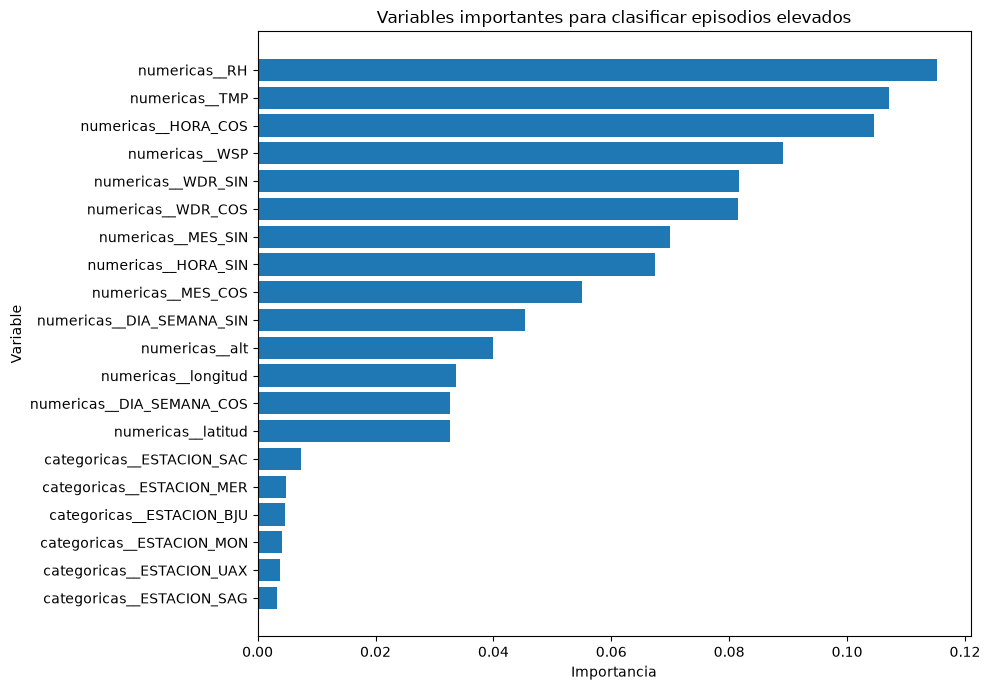

In [67]:
top_importancias = (
    tabla_importancias
    .head(20)
    .sort_values(
        by="importancia",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_importancias["variable"],
    top_importancias["importancia"]
)

plt.title(
    "Variables importantes para clasificar episodios elevados"
)
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS
    / "importancia_variables_clasificacion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretación de la importancia de variables

La humedad relativa, la temperatura, la hora del día, la velocidad y dirección del viento fueron las variables con mayor importancia predictiva. También contribuyeron la estacionalidad mensual, la altitud y la ubicación geográfica.

Estos resultados indican que la identificación de episodios elevados depende de la combinación de factores meteorológicos, temporales y espaciales, y no de una sola variable de manera aislada.

In [68]:
ruta_predicciones = (
    CARPETA_RESULTADOS
    / "clasificacion_episodios_2025.csv"
)

resultados_prueba.to_csv(
    ruta_predicciones,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Predicciones guardadas:",
    ruta_predicciones.exists()
)

Predicciones guardadas: True


In [69]:
desempeno_estaciones.to_csv(
    CARPETA_TABLAS
    / "clasificacion_por_estacion.csv",
    index=False,
    encoding="utf-8-sig"
)

In [70]:
tabla_importancias.to_csv(
    CARPETA_TABLAS
    / "importancia_variables_clasificacion.csv",
    index=False,
    encoding="utf-8-sig"
)

In [71]:
tabla_umbral = pd.DataFrame({
    "criterio": [
        "Percentil 90 de entrenamiento"
    ],
    "anio_entrenamiento": [2024],
    "umbral_pm25": [umbral_p90]
})

tabla_umbral.to_csv(
    CARPETA_TABLAS
    / "umbral_exploratorio_pm25.csv",
    index=False,
    encoding="utf-8-sig"
)

In [72]:
joblib.dump(
    modelo_dummy,
    CARPETA_MODELOS
    / "dummy_classifier_episodios.joblib"
)

['..\\resultados\\modelos\\dummy_classifier_episodios.joblib']

In [73]:
joblib.dump(
    modelo_logistico,
    CARPETA_MODELOS
    / "regresion_logistica_episodios.joblib"
)

['..\\resultados\\modelos\\regresion_logistica_episodios.joblib']

In [74]:
joblib.dump(
    modelo_rf_clasificacion,
    CARPETA_MODELOS
    / "random_forest_classifier_episodios.joblib"
)

print(
    "Modelos de clasificación guardados"
)

Modelos de clasificación guardados


In [75]:
for archivo in sorted(
    CARPETA_MODELOS.glob(
        "*classifier*.joblib"
    )
):
    print(archivo.name)

dummy_classifier_episodios.joblib
random_forest_classifier_episodios.joblib


In [76]:
figuras_generadas = sorted(
    CARPETA_FIGURAS.glob("*.png")
)

print(
    "Cantidad de figuras:",
    len(figuras_generadas)
)

for figura in figuras_generadas:
    print(figura.name)

Cantidad de figuras: 8
comparacion_f1.png
comparacion_pr_auc.png
comparacion_recall.png
curva_precision_recall.png
curva_roc.png
importancia_variables_clasificacion.png
matriz_confusion_logistica.png
matriz_confusion_random_forest.png


# Conclusiones de la clasificación experimental

Se desarrollaron modelos especializados para identificar registros con concentraciones elevadas de PM2.5, utilizando provisionalmente el percentil 90 del conjunto de entrenamiento como umbral estadístico.

La evaluación temporal utilizó datos de 2024 para entrenamiento y datos de 2025 para prueba. Se comparó un modelo de referencia, una regresión logística balanceada y un Random Forest Classifier con ponderación de clases.

Debido al desbalance entre episodios elevados y no elevados, los modelos fueron evaluados mediante precision, recall, F1, ROC-AUC y PR-AUC, además de las matrices de confusión.

El análisis permitió determinar qué modelo presenta mayor capacidad para detectar la clase minoritaria y reducir los falsos negativos respecto al experimento de regresión. También se examinó el desempeño por estación y la importancia predictiva de las variables meteorológicas, temporales, espaciales y categóricas.

Los resultados son experimentales. El percentil 90 deberá sustituirse o complementarse con un criterio ambiental o sanitario validado antes de utilizar el modelo como sistema de alerta o de identificación definitiva de zonas críticas.